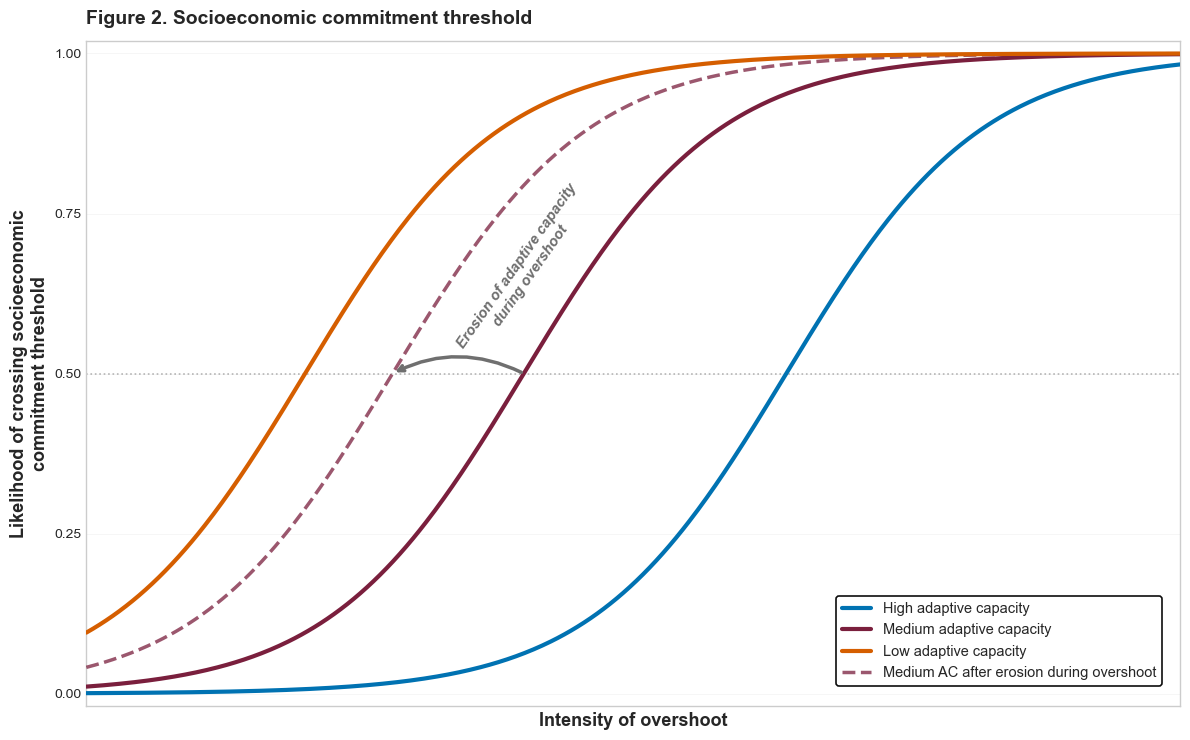

Figure 2 saved.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ----------------------------
# Style (matched to Figure 1)
# ----------------------------
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.style.use('seaborn-v0_8-whitegrid')

# ----------------------------
# Colours (matched to Figure 1)
# ----------------------------
COL_REV = '#0072B2'         # blue (high adaptive capacity / resilient)
COL_NONREV = '#D55E00'      # orange (low adaptive capacity / vulnerable)
COL_MED = '#7a1f3d'         # burgundy (medium, matches Panel A forcing colour)
COL_SHADE = '#d9d9d9'       # light grey for scenario band
COL_GREY = '#6f6f6f'        # secondary text/lines

# ----------------------------
# Sigmoid function for S-curves
# ----------------------------
def sigmoid(x, midpoint, steepness):
    """Logistic sigmoid: probability = 1 / (1 + exp(-steepness*(x - midpoint)))"""
    return 1.0 / (1.0 + np.exp(-steepness * (x - midpoint)))

# ----------------------------
# Data generation
# ----------------------------
# X-axis: overshoot integral in degree-years
x = np.linspace(0, 25, 500)

# Three adaptive capacity levels shift the midpoint
# Low AC: crosses threshold at lower degree-years (leftward)
# High AC: requires more degree-years (rightward)
mid_low = 5.0
mid_med = 10.0
mid_high = 16.0
steep = 0.45  # common steepness for all curves

p_low = sigmoid(x, mid_low, steep)
p_med = sigmoid(x, mid_med, steep)
p_high = sigmoid(x, mid_high, steep)

# Eroded adaptive capacity curve (medium AC shifting toward low AC over time)
# This represents the dynamic feedback: as overshoot persists, AC erodes
mid_eroded = 7.0  # shifted leftward from medium
p_eroded = sigmoid(x, mid_eroded, steep)

# ----------------------------
# Plotting
# ----------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 7.5))

# Grid
ax.grid(True, alpha=0.25, linewidth=0.5)
ax.set_axisbelow(True)

# Main S-curves
ax.plot(x, p_high, color=COL_REV, linewidth=3.0, label='High adaptive capacity',
        zorder=4)
ax.plot(x, p_med, color=COL_MED, linewidth=3.0, label='Medium adaptive capacity',
        zorder=4)
ax.plot(x, p_low, color=COL_NONREV, linewidth=3.0, label='Low adaptive capacity',
        zorder=4)

# Eroded AC curve (dashed, showing dynamic shift)
ax.plot(x, p_eroded, color=COL_MED, linewidth=2.5, linestyle='--',
        label='Medium AC after erosion during overshoot', zorder=3, alpha=0.75)

# Arrow showing the leftward shift from medium to eroded
# Place arrow at the p=0.5 level for clarity
arrow_y = 0.5
arrow_x_start = mid_med
arrow_x_end = mid_eroded
ax.annotate('',
            xy=(arrow_x_end, arrow_y),
            xytext=(arrow_x_start, arrow_y),
            arrowprops=dict(arrowstyle='->', color=COL_GREY, lw=2.5,
                            connectionstyle='arc3,rad=0.25'),
            zorder=5)
ax.text((arrow_x_start + arrow_x_end) / 1.7, arrow_y + 0.02,
        'Erosion of adaptive capacity\nduring overshoot',
        fontsize=10.5, color=COL_GREY, fontweight='bold',
        ha='center', va='bottom', style='italic', rotation=55)


# Horizontal dashed line at p=0.5 for reference
ax.axhline(0.5, color=COL_GREY, linestyle=':', linewidth=1.2, alpha=0.5, zorder=1)

# Labels and formatting
ax.set_xlabel('Intensity of overshoot', fontsize=13,
              fontweight='bold')
ax.set_ylabel('Likelihood of crossing socioeconomic\ncommitment threshold', fontsize=13,
              fontweight='bold')
ax.set_title('Figure 2. Socioeconomic commitment threshold',
             loc='left', fontsize=14, fontweight='bold', pad=12)

ax.set_xlim(0, 25)
ax.set_ylim(-0.02, 1.02)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticks([])  # hide x-ticks since we use custom annotations instead

# Legend
leg = ax.legend(loc='lower right', frameon=True, fontsize=10.5,
                framealpha=0.95, edgecolor='black',
                bbox_to_anchor=(0.99, 0.02))
leg.get_frame().set_linewidth(1.2)


plt.tight_layout()
plt.savefig('figure2.png', dpi=800, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")
